In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# 读取数据
df = pd.read_csv('interactions.csv')
print(df.head(10))
print(f"数据集大小: {df.shape}")
print(f"标签分布:\n{df['label'].value_counts()}")

  user_id item_id  label
0     U01     I14      1
1     U01     I17      0
2     U01     I04      0
3     U01     I16      0
4     U01     I20      0
5     U01     I12      1
6     U01     I10      0
7     U01     I18      1
8     U01     I06      0
9     U01     I07      1
数据集大小: (120, 3)
标签分布:
0    63
1    57
Name: label, dtype: int64


In [141]:
# 将 user_id 和 item_id 映射为连续索引
user_ids = df['user_id'].unique()
item_ids = df['item_id'].unique()
user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {it: i for i, it in enumerate(item_ids)}

num_users = len(user2idx)
num_items = len(item2idx)
print(f"用户数: {num_users}, 物品数: {num_items}")

# 添加索引列
df['user_idx'] = df['user_id'].map(user2idx)
df['item_idx'] = df['item_id'].map(item2idx)

# 划分训练集、验证集、测试集(4：1：1)
# 随机打乱并划分数据集
df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
train_df = df.iloc[:80]
val_df = df.iloc[80:100]
test_df = df.iloc[100:]

print(f"训练集大小: {len(train_df)}, 验证集大小: {len(val_df)}, 测试集大小: {len(test_df)}")

用户数: 12, 物品数: 20
训练集大小: 80, 验证集大小: 20, 测试集大小: 20


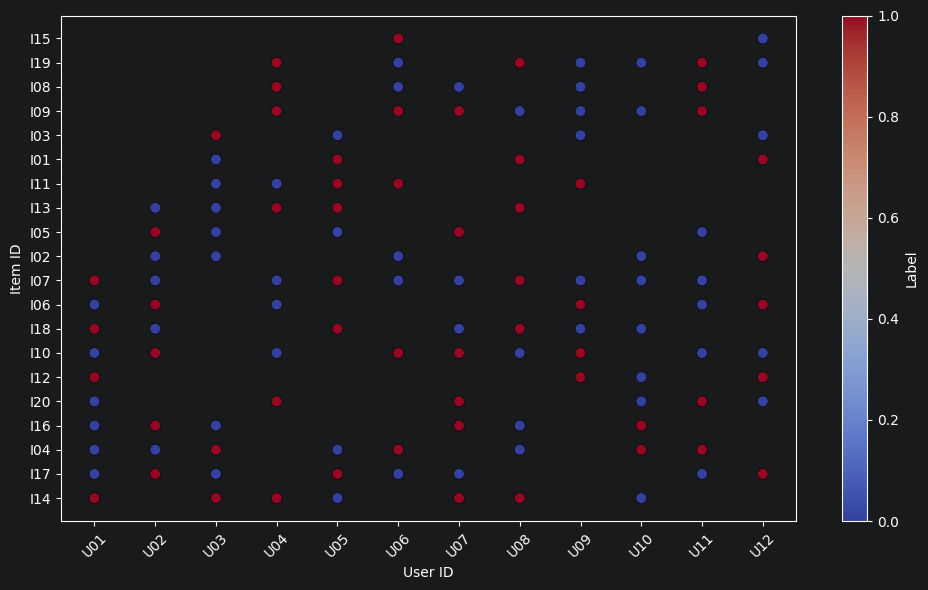

In [3]:
#可视化原始二维数据分布
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['user_idx'], df['item_idx'],
    c=df['label'], cmap='coolwarm', alpha=0.8,
    edgecolors='k', linewidths=0.5, s=60
)
plt.colorbar(scatter, label='Label')

plt.xticks(range(len(user_ids)), user_ids, rotation=45)
plt.yticks(range(len(item_ids)), item_ids)
plt.xlabel('User ID')
plt.ylabel('Item ID')
plt.tight_layout()
plt.show()

In [4]:
class IntDataset(Dataset):
    def __init__(self, df):
        self.users = torch.LongTensor(df['user_idx'].values)
        self.items = torch.LongTensor(df['item_idx'].values)
        self.labels = torch.FloatTensor(df['label'].values)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]

# 创建 Dataset 和 DataLoader
batch_size = 16
train_dataset = IntDataset(train_df)
val_dataset = IntDataset(val_df)
test_dataset = IntDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("训练集batch数量：", len(train_loader))
batch_user, batch_item, batch_labels = next(iter(train_loader))
print("batch_user.shape：", batch_user.shape)
print("batch_item.shape：  ", batch_item.shape)
print("batch_labels.shape：  ", batch_labels.shape)
print("features dtype：", batch_user.dtype)
print("features dtype：", batch_item.dtype)
print("labels dtype：  ", batch_labels.dtype)
print("第一条样本：", batch_user[0], batch_item[0], "label=", batch_labels[0])

训练集batch数量： 5
batch_user.shape： torch.Size([16])
batch_item.shape：   torch.Size([16])
batch_labels.shape：   torch.Size([16])
features dtype： torch.int64
features dtype： torch.int64
labels dtype：   torch.float32
第一条样本： tensor(6) tensor(1) label= tensor(0.)


In [5]:
#模型定义
class TwoDimClassifier(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=2):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, embedding_dim)
        self.item_emb = nn.Embedding(num_items, embedding_dim)
        # 初始化
        nn.init.normal_(self.user_emb.weight, mean=0, std=0.1)
        nn.init.normal_(self.item_emb.weight, mean=0, std=0.1)

    def forward(self, user_idx, item_idx):
        u = self.user_emb(user_idx)
        v = self.item_emb(item_idx)
        # 点积作为 logit
        logits = (u * v).sum(dim=1)
        return logits

    def get_features(self, user_idx, item_idx):
        u = self.user_emb(user_idx)
        v = self.item_emb(item_idx)
        return (u * v).detach().cpu().numpy()

# 实例化模型
model = TwoDimClassifier(num_users, num_items, embedding_dim=2)
print("模型结构：")
print(model)


模型结构：
TwoDimClassifier(
  (user_emb): Embedding(12, 2)
  (item_emb): Embedding(20, 2)
)


Epoch   1/300 | Train Loss: 0.6926 | Val Loss: 0.6917
Epoch  50/300 | Train Loss: 0.6880 | Val Loss: 0.6908
Epoch 100/300 | Train Loss: 0.6747 | Val Loss: 0.6872
Epoch 150/300 | Train Loss: 0.6364 | Val Loss: 0.6757
Epoch 200/300 | Train Loss: 0.5593 | Val Loss: 0.6517
Epoch 250/300 | Train Loss: 0.4709 | Val Loss: 0.6274
Epoch 300/300 | Train Loss: 0.4005 | Val Loss: 0.6179


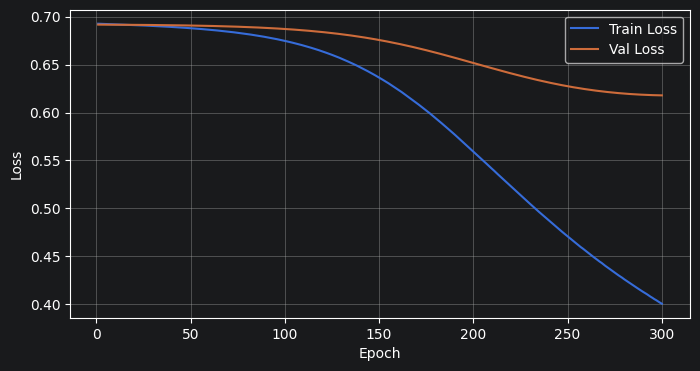

In [146]:
model = TwoDimClassifier(num_users, num_items, embedding_dim=2)
criterion = nn.BCEWithLogitsLoss() #损失函数
optimizer = torch.optim.SGD(model.parameters(), lr=0.1) #优化器

train_losses = []
val_losses = []

#循环训练模型
epochs = 300
for epoch in range(1, epochs + 1):
    model.train()
    total_train_loss = 0
    for users, items, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(users, items)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * len(users)
    avg_train_loss = total_train_loss / len(train_dataset)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for users, items, labels in val_loader:
            outputs = model(users, items)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item() * len(users)
    avg_val_loss = total_val_loss / len(val_dataset)
    val_losses.append(avg_val_loss)


    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# 绘制 Loss 曲线
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [53]:
#展示验证集结果
model.eval()
val_preds = []
val_labels = []
with torch.no_grad():
    for users, items, labels in val_loader:
        outputs = model(users, items)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int()
        val_preds.extend(preds.cpu().numpy())
        val_labels.extend(labels.int().cpu().numpy())

val_acc = accuracy_score(val_labels, val_preds)
val_auc = roc_auc_score(val_labels, val_preds)
print(f"验证集准确率: {val_acc:.4f}")
print(f"验证集 AUC: {val_auc:.4f}")

验证集准确率: 0.7500
验证集 AUC: 0.7424


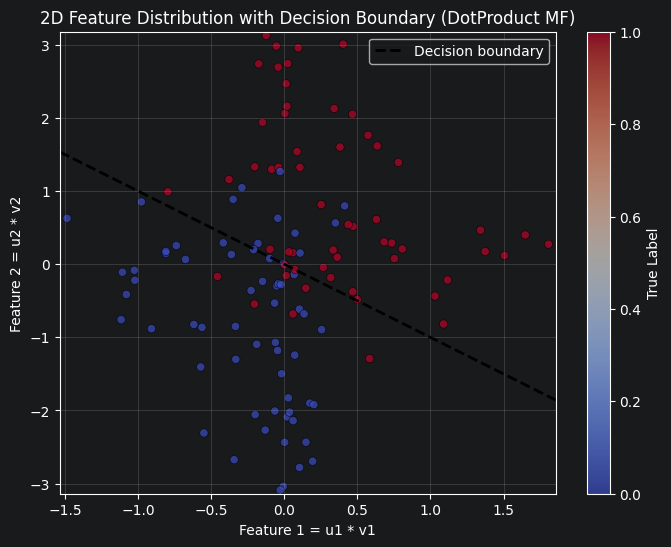

In [54]:
# 二维数据分布
# 提取全部交互的二维哈达玛积特征
all_users = torch.LongTensor(df['user_idx'].values)
all_items = torch.LongTensor(df['item_idx'].values)
all_labels = df['label'].values

model.eval()
with torch.no_grad():
    features_2d = model.get_features(all_users, all_items)  # (N, 2)

# 绘图设置
plt.figure(figsize=(8, 6))
sc = plt.scatter(features_2d[:, 0], features_2d[:, 1],
                 c=all_labels, cmap='coolwarm', alpha=0.7,
                 edgecolors='k', linewidths=0.5)
plt.colorbar(sc, label='True Label')
plt.xlabel('Feature 1 = u1 * v1')
plt.ylabel('Feature 2 = u2 * v2')
plt.title('2D Feature Distribution with Decision Boundary (DotProduct MF)')

# 绘制决策边界：点积 = u1*v1 + u2*v2 = 0
x_min, x_max = features_2d[:, 0].min() - 0.05, features_2d[:, 0].max() + 0.05
x_line = np.linspace(x_min, x_max, 100)
y_line = -x_line
plt.plot(x_line, y_line, 'k--', linewidth=2, label='Decision boundary')

plt.xlim(x_min, x_max)
plt.ylim(features_2d[:,1].min()-0.05, features_2d[:,1].max()+0.05)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [56]:
#使用测试集进行预测
model.eval()
test_probs = []
test_labels = []
with torch.no_grad():
    for users, items, labels in test_loader:
        outputs = model(users, items)
        probs = torch.sigmoid(outputs)
        test_probs.extend(probs.cpu().numpy())
        test_labels.extend(labels.int().cpu().numpy())

test_preds = [1 if p > 0.5 else 0 for p in test_probs]
test_acc = accuracy_score(test_labels, test_preds)
test_auc = roc_auc_score(test_labels, test_probs)

print(f"测试集准确率: {test_acc:.4f}")
print(f"测试集 AUC: {test_auc:.4f}")

测试集准确率: 0.6500
测试集 AUC: 0.6979
